Assuming you have read the `README.md` and imported `networkx`,


In [3]:
import networkx as nx

the key files you should know about are:


### `graphs/undirected_graphs.py`

This stores predefined common graphs such as paths, cycles, stars, wheels, and more. I have imported them all below.


In [3]:
from graphs import (
    PathGraph,
    CycleGraph,
    CompleteGraph,
    StarGraph,
    SunGraph,
    WheelGraph,
    UndirectedGraph,
)

Note: `UndirectedGraph` is just the superclass of all specific types of graph - it should not be instantiated itself!

Each graph class has a standard vertex numbering - this is completely unrelated to labellings and is just a way of giving the vertices unique names to reference in the edges. The edges are accessed by calling `<graph_class>.edges(n_vertices)`, here are some examples:


In [4]:
print(PathGraph.edges(4))
print(CycleGraph.edges(4))
print(CompleteGraph.edges(4))
print(StarGraph.edges(7))

[(0, 1), (1, 2), (2, 3)]
[(0, 1), (1, 2), (2, 3), (3, 0)]
[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
[(7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6)]


Again, the specific numbers above mean nothing to the code and are just a vehicle for the edges. Each graph class also contains a `.layout(n_vertices)` method used to visualised the graphs later.


### `graphs/tools/drawing.py`


The sole function `draw_graphs` is to visualise stand-alone graphs or a collection of graphs (the worth of which will become clear when finding labellings). Simply pass as its first argument a `networkx` graph (created by calling `nx.Graph` with an edge sets defined earlier), along with the (optional) layout.


In [5]:
from graphs.tools import draw_graphs

Here are visualisations of our standard unlabelled graph types:


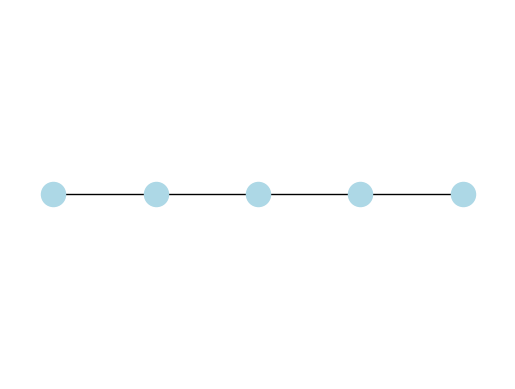

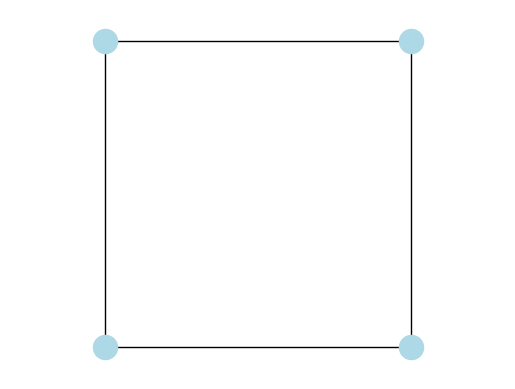

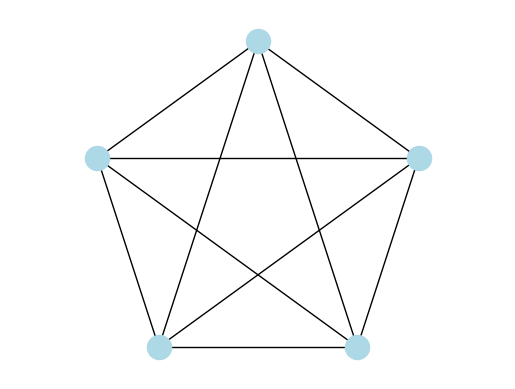

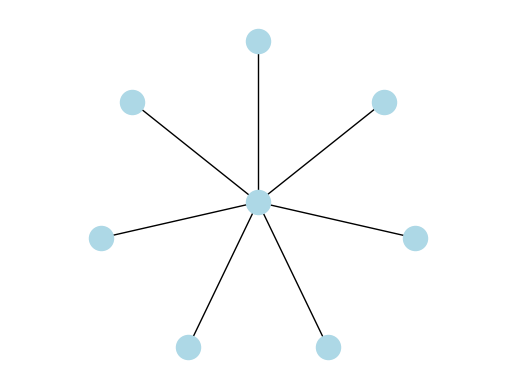

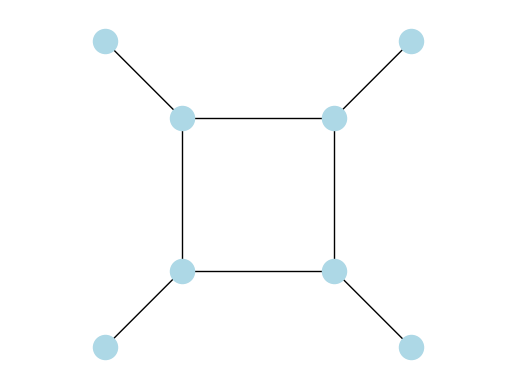

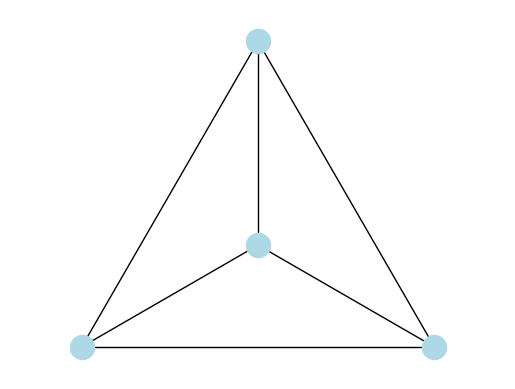

In [6]:
to_draw: list[tuple[type[UndirectedGraph], int]] = [
    (PathGraph, 5),
    (CycleGraph, 4),
    (CompleteGraph, 5),
    (StarGraph, 7),
    (SunGraph, 4),
    (WheelGraph, 4),
]

for graph_class, n_vertices in to_draw:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)

    draw_graphs(graph, layout=layout)

A note on the layout; it is only an optional argument to the `draw_graphs` function, however its omission defaults `networkx`'s graph drawing algorithm to the 'Fruchterman-Reingold force-directed algorithm', which may produce cluttered or unintuitive visualisations.


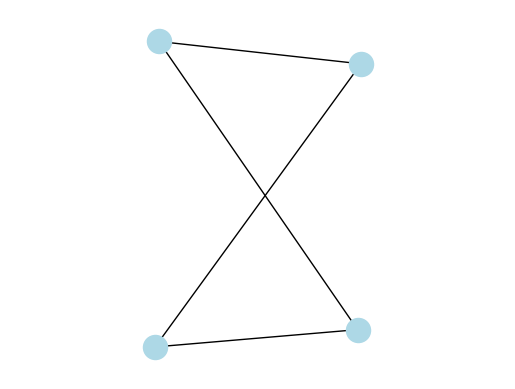

In [21]:
graph = nx.Graph(CycleGraph.edges(4))
draw_graphs(graph)

Further, should you choose, you can mismatch graph and layout, e.g. visualising $P_4$ as $C_4$. I would not recommend, however, visualising $C_4$ as $P_4$.


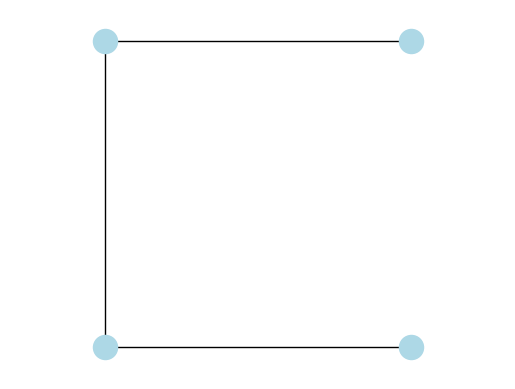

In [8]:
graph = nx.Graph(PathGraph.edges(4))
draw_graphs(graph, layout=CycleGraph.layout(4))

What if you want to create a custom graph that is not predefined? Mimicking the process used in `<graph_class>.edges`, we create an abstract numbering to represent the structure of edges, e.g. here we recreate Rosa's pesky star:


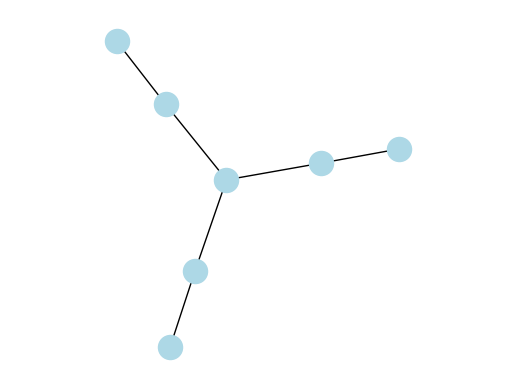

In [ ]:
rosas_star = [(0, 1), (1, 2), (0, 3), (3, 4), (0, 5), (5, 6)]

graph = nx.Graph(rosas_star)
draw_graphs(graph)

Alternatively, to really hammer home the point that the vertex numbers do not matter, here is the same graph created using strings:


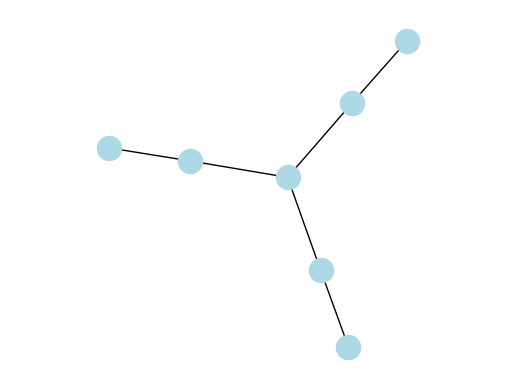

In [ ]:
rosas_dwarf_star = [
    ("Doc", "Grumpy"),
    ("Grumpy", "Happy"),
    ("Doc", "Sleepy"),
    ("Sleepy", "Bashful"),
    ("Doc", "Sneezy"),
    ("Sneezy", "Dopey"),
]

graph = nx.Graph(rosas_dwarf_star)
draw_graphs(graph)

### `graphs/graceful_labellings/main.py`

Finally, the algorithms:


In [ ]:
from graphs.graceful_labellings import (
    find_graceful_labellings,
    find_alpha_valuations,
    find_eta_valuations,
)

These algorithms return (possibly empty) collections of graphs. They do not care about the vertex names and create independent labels for each vertex. Naturally these algorithms run in factorial-like time, although to improve performance early exit is performed on specific labellings if the same edge label is seen twice. Using `draw_graphs` a slideshow is created so you can 'horizontally scroll' the outputted graphs:



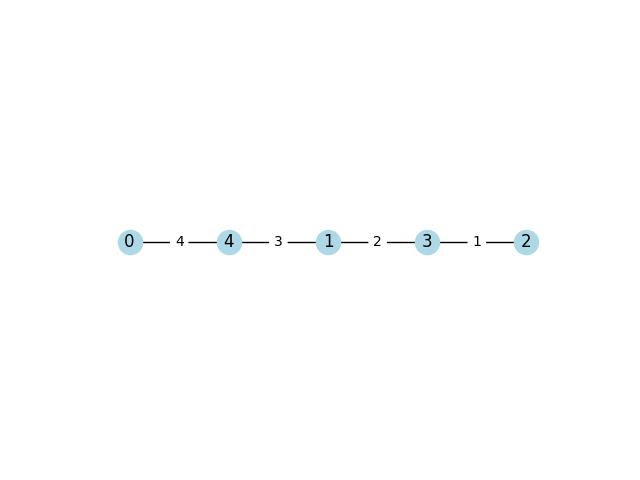


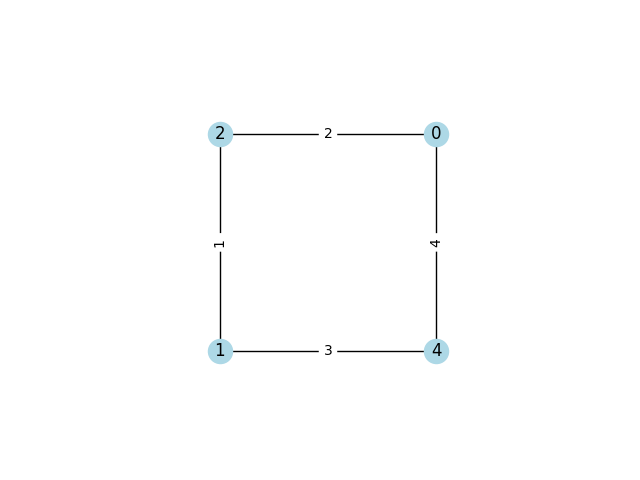


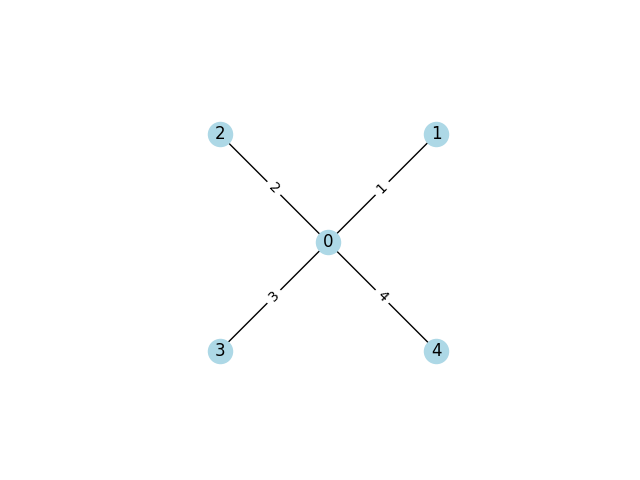

No graceful labellings found.


In [23]:
to_label: list[tuple[type[UndirectedGraph], int]] = [
    (PathGraph, 5),
    (CycleGraph, 4),
    (StarGraph, 4),
    (CycleGraph, 5),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)
    labellings = find_graceful_labellings(graph)

    try:
        draw_graphs(labellings, layout=layout)
    except StopIteration:
        print("No graceful labellings found.")


Note that the above algorithm 'overcounts' the graceful labellings as it doesn't consider graph automorphisms - I would assume since $C_4$ has automorphism group $D_8$ we can deduce it only has 2 distinct (up to automorphisms) graceful labellings? Similarly the star graph on 5 vertices has automorphism group $\mathbb{S}_4$ and thus also 2 distinct graceful labellings? By a reflection-across-the-middle argument $P_5$ has 4 distinct graceful labellings?

Should you ever be working with a graph with a lot of edges and only want to find a singular labelling rather than waiting for the factorial-like algorithm to complete, Python's `next` function can be used as follows:


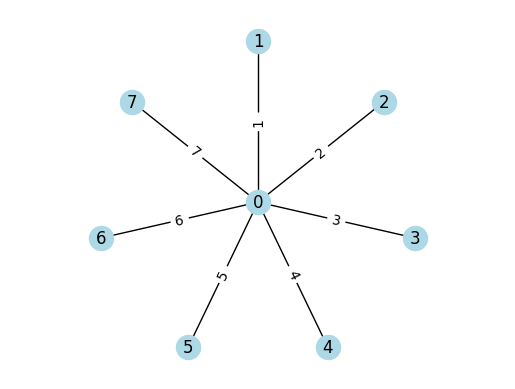

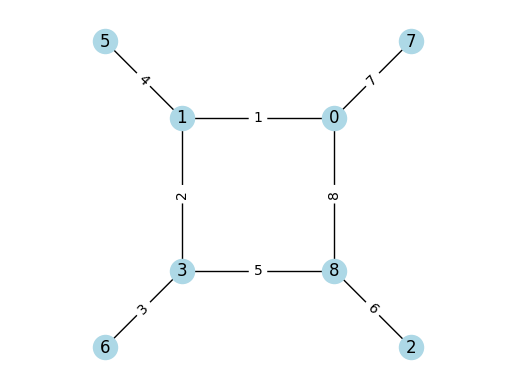

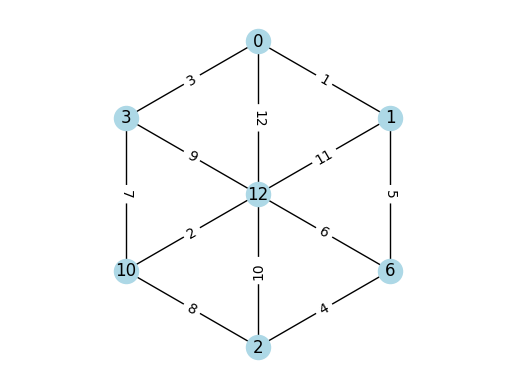

In [ ]:
to_label: list[tuple[type[UndirectedGraph], int]] = [
    (StarGraph, 7),
    (SunGraph, 4),
    (WheelGraph, 7),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)

    try:
        labelling = next(find_graceful_labellings(graph))
    except StopIteration:
        print("No graceful labellings found.")
    else:
        draw_graphs(labelling, layout=layout)


Lightning fast - try getting all labellings and you'll be there a short while.

The other two algorithms are simply filters on the `find_graceful_labellings` algorithm. Here are there outputs for $\alpha$-valuations:



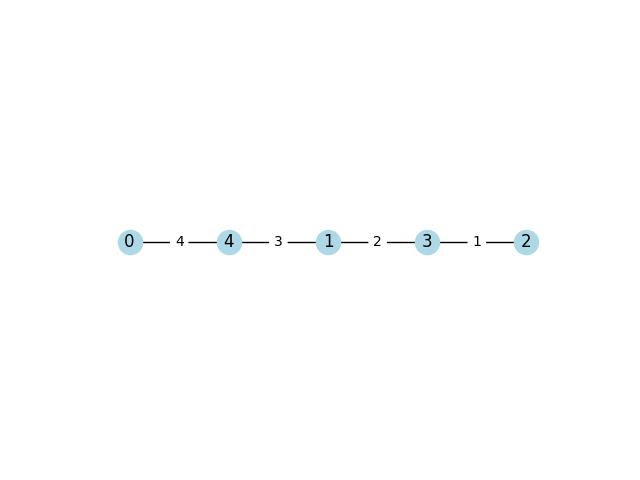


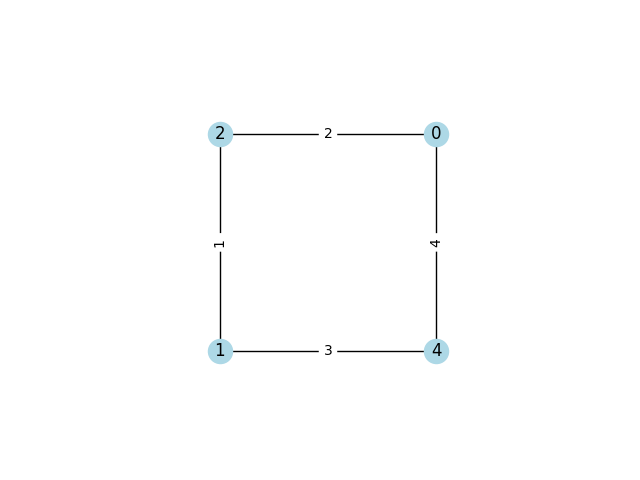


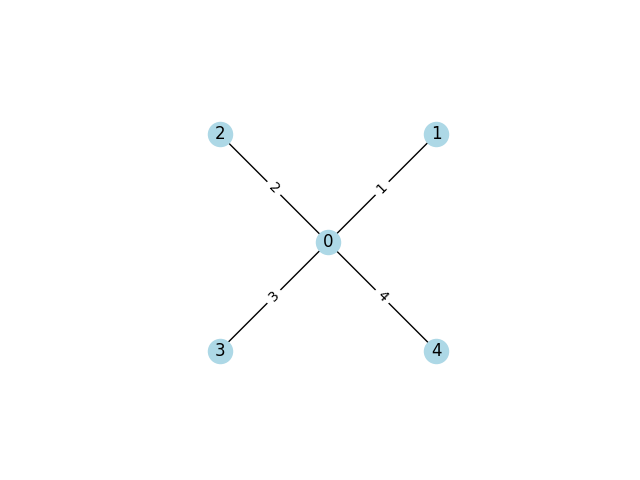

No alpha-valuations found.


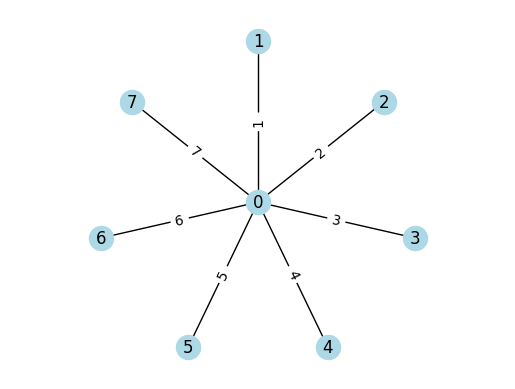

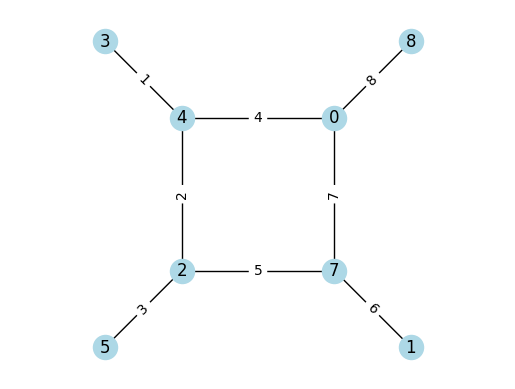

No alpha-valuations found.


In [24]:
to_label: list[tuple[type[UndirectedGraph], int]] = [
    (PathGraph, 5),
    (CycleGraph, 4),
    (StarGraph, 4),
    (CycleGraph, 5),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)
    labellings = find_alpha_valuations(graph)

    try:
        draw_graphs(labellings, layout=layout)
    except StopIteration:
        print("No alpha-valuations found.")

to_label: list[tuple[type[UndirectedGraph], int]] = [
    (StarGraph, 7),
    (SunGraph, 4),
    (WheelGraph, 7),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)

    try:
        labelling = next(find_alpha_valuations(graph))
    except StopIteration:
        print("No alpha-valuations found.")
    else:
        draw_graphs(labelling, layout=layout)

And $\eta$-valuations:



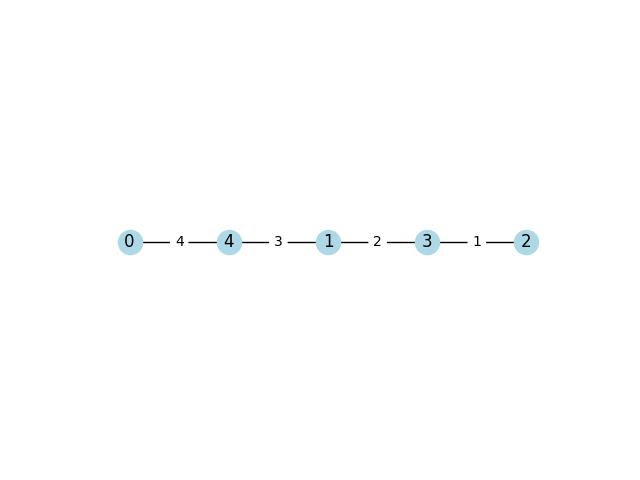

No eta-valuations found.



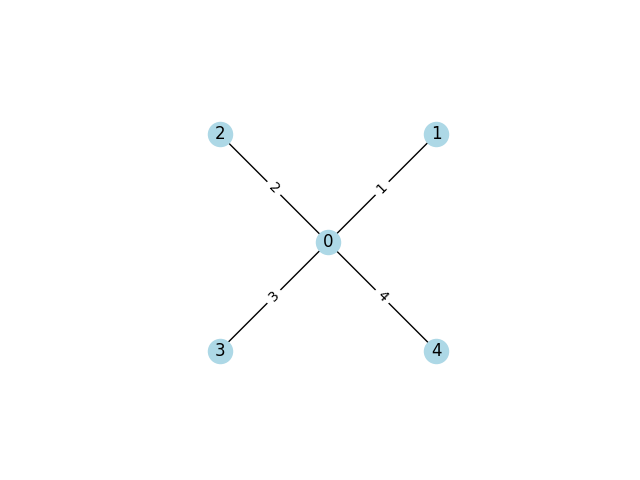

No eta-valuations found.


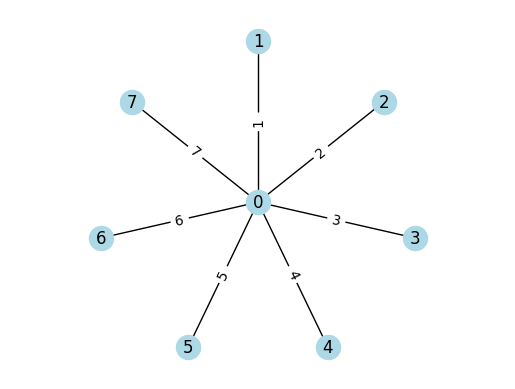

No eta-valuations found.
No eta-valuations found.


In [25]:
to_label: list[tuple[type[UndirectedGraph], int]] = [
    (PathGraph, 5),
    (CycleGraph, 4),
    (StarGraph, 4),
    (CycleGraph, 5),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)
    labellings = find_eta_valuations(graph)

    try:
        draw_graphs(labellings, layout=layout)
    except StopIteration:
        print("No eta-valuations found.")

to_label: list[tuple[type[UndirectedGraph], int]] = [
    (StarGraph, 7),
    (SunGraph, 4),
    (WheelGraph, 7),
]

for graph_class, n_vertices in to_label:
    edges = graph_class.edges(n_vertices)
    layout = graph_class.layout(n_vertices)
    graph = nx.Graph(edges)

    try:
        labelling = next(find_eta_valuations(graph))
    except StopIteration:
        print("No eta-valuations found.")
    else:
        draw_graphs(labelling, layout=layout)


Lets perform all three algorithms on Rosa's star (I'll use the dwarf star again) and hopefully we'll see that there are only the standard graceful labellings:



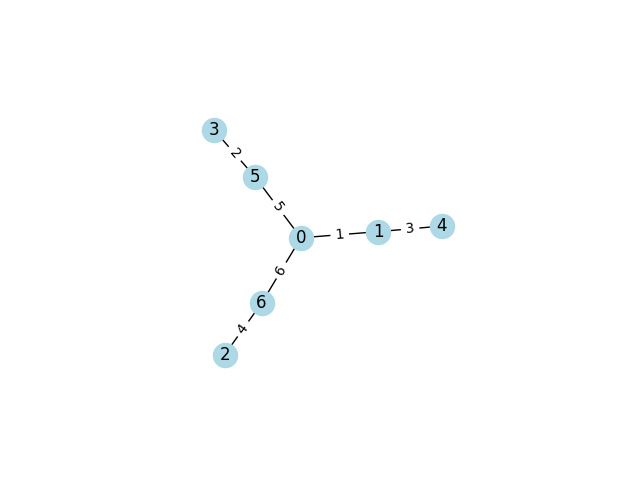

No alpha-valuations found.
No eta-valuations found.


In [27]:
graph = nx.Graph(rosas_dwarf_star)

try:
    draw_graphs(find_graceful_labellings(graph))
except StopIteration:
    print("No graceful labellings found.")

try:
    draw_graphs(find_alpha_valuations(graph))
except StopIteration:
    print("No alpha-valuations found.")

try:
    draw_graphs(find_eta_valuations(graph))
except StopIteration:
    print("No eta-valuations found.")

Lastly, some fun non-tree graphs with $\eta$-valuations. If any of `networkx`'s default visualisations look bad, just run the code again.



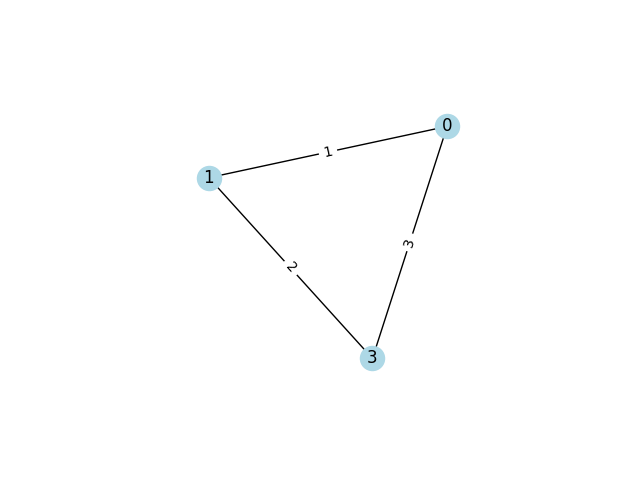


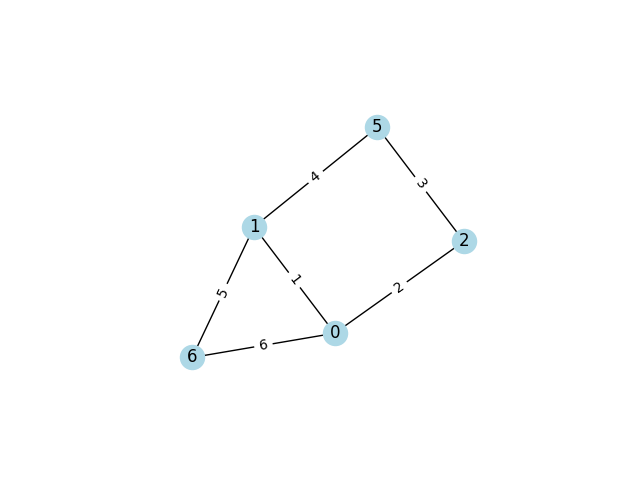


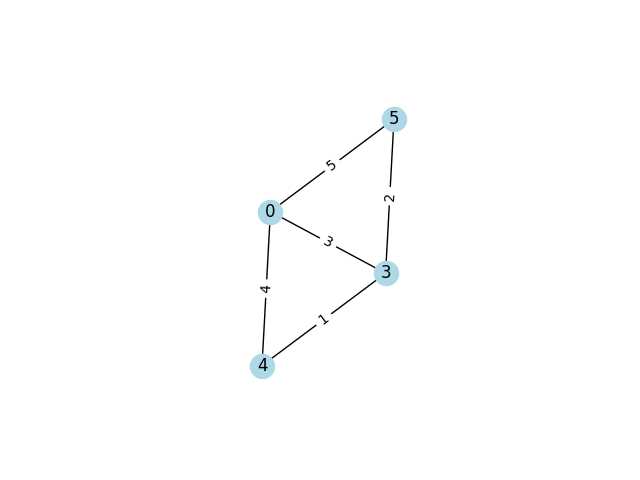

In [29]:
edge_sets = [
    CycleGraph.edges(3),
    CycleGraph.edges(3) + [(0, 3), (3, 4), (4, 1)],
    CycleGraph.edges(3) + [(0, 3), (3, 1)],
]

for edges in edge_sets:
    graph = nx.Graph(edges)
    eta_valuations = find_eta_valuations(graph)
    draw_graphs(eta_valuations)

Gavin
